In [ ]:
# Quantification of U reactivity in single-strand (SS) and double-strand (DS) regions of COX1 mRNA for PRADA-MaP seq 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO 

In [ ]:
## 1. Extend Figure 6b --- --- 

In [2]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [3]:
#### A. input 

dir = "./Data/"
prada = pd.read_csv(dir+'PRADA_vitro_4sU_mito_NC_012920.1_profile.txt',sep='\t')
cox1= prada[(prada['Nucleotide']>=5900) & (prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1 = cox1[(cox1['Modified_effective_depth']>=5000) & (cox1['Untreated_effective_depth']>=5000)]

cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 
dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])

#### D. SS and DS regions
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)
dplott = dplot[(dplot['base'] =='T') | (dplot['base'] =='U')]

dplott.to_csv('./Data/'+'source_data_Efig6b.csv',sep=',')

(1618, 8)


/tmp/ipykernel_129147/50748556.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_129147/50748556.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.747e-15 U_stat=2.415e+04


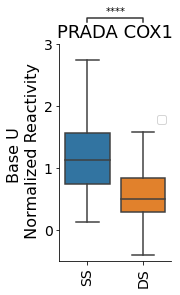

In [4]:
#### plot 

plt.figure(figsize=(2,4))

order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 

plt.title('PRADA COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base U \n Normalized Reactivity',fontsize = 16)
plt.ylim(-0.5,3)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks([0.0,1.0,2.0,3.0],fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='outside', line_offset_to_box=0.1, verbose=3)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig6b_PRADA_COX1_baseU_react_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 

In [7]:
print(dplott.groupby(["region"]).count())  

        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS              96        96                        96   
SS             328       328                       328   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                             96             96              96   
SS                            328            328             328   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                      96            96         96    96   96      96  
SS                     328           328        328   328  328     328  
